# 04 — Kampanya ve Kupon EDA'sı

## Amaç

Bu notebook, hanelerin aldığı kampanyaları, kampanyaların zaman ve erişim yapısını,
kupon havuzlarını ve gerçekleşen kupon kullanımlarını birlikte inceler. Amaç yalnızca
kaç kupon kullanıldığını saymak değil; hangi oranların User Guide'a göre güvenilir
biçimde hesaplanabileceğini ve modellemeye hangi kampanya özelliklerinin aktarılacağını
belirlemektir.

### Cevaplanacak sorular

1. Kampanya, katılımcı hane ve kupon tabloları birbiriyle tutarlı mı?
2. Kampanya tipleri süre, erişim ve kupon havuzu bakımından nasıl farklılaşıyor?
3. Kupon kullanımları doğru kampanya döneminde ve kampanyayı alan hanelerde mi gerçekleşiyor?
4. Type A ile Type B/C için hangi kullanım oranları hesaplanabilir?
5. Katılımcı hanelerin kampanya öncesi ve kampanya dönemi davranışı nasıl değişiyor?
6. Hane düzeyinde hangi kampanya ve kupon özellikleri üretilebilir?

### User Guide'a göre tablo rolleri

- `campaign_table`: Her hanenin aldığı kampanyaları gösterir; farklı haneler farklı
  kampanya kümeleri alabilir.
- `campaign_desc`: Kampanya tipini ve kuponların geçerli olduğu başlangıç/bitiş
  günlerini gösterir.
- `coupon`: Kupon–ürün ilişkisini gösterir. Aynı kupon birden fazla üründe geçerli
  olabileceği için bir kupon birden fazla satırda bulunabilir. Type A için bu tablo
  gönderilen kuponları değil, seçim yapılan **olası kupon havuzunu** temsil eder.
- `coupon_redempt`: Hanelerin fiilen kullandığı kuponları ve kullanım gününü gösterir.

### Kritik kampanya kuralı

- **Type A:** Her katılımcı hane, kampanya havuzundan geçmiş davranışına göre seçilen
  16 kuponu alır; hangi 16 kuponun gönderildiği veri setinde bulunmaz. Bu nedenle
  gerçek kullanım oranının paydası bilinmez.
- **Type B / Type C:** Katılımcı haneler kampanyadaki bütün kuponları alır. Bu
  kampanya tiplerinde benzersiz kupon kullanım oranı hesaplanabilir.

> **Temel yorumlama sınırı:** Bu notebook tanımlayıcı analiz yapar. Kampanya alan
> haneler rastgele seçilmediği ve kontrol grubu kurulmadığı için kampanyanın harcama
> artışına **neden olduğu** sonucuna varılmaz.


## 1. Kütüphaneler, yollar ve verinin yüklenmesi

`01_data_preparation` notebook'unda temizlenip `data/interim` altında saklanan beş
tablo yüklenir. Böylece kupon tekrarları ve sütun standardizasyonu bakımından önceki
notebook'larla aynı veri sürümü kullanılır. Parquet bulunamazsa ham CSV okunur.


In [18]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 240)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


def first_existing_path(candidates):
    """İlk bulunan klasörü döndürür; bulunamazsa açıklayıcı hata verir."""
    for candidate in candidates:
        candidate = Path(candidate)
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        "Veri klasörü bulunamadı. Beklenen seçenekler: "
        + ", ".join(map(str, candidates))
    )


RAW_PATH = first_existing_path([
    "data/raw",
    "../data/raw",
    "data_raw",
    "../data_raw",
])

if RAW_PATH.name == "raw":
    DATA_ROOT = RAW_PATH.parent
else:
    DATA_ROOT = RAW_PATH.parent / "data"

PROCESSED_PATH = DATA_ROOT / "processed"
INTERIM_PATH = DATA_ROOT / "interim"

PROCESSED_PATH.mkdir(parents=True, exist_ok=True)
INTERIM_PATH.mkdir(parents=True, exist_ok=True)

print(f"Ham veri klasörü : {RAW_PATH.resolve()}")
print(f"İşlenmiş veri    : {PROCESSED_PATH.resolve()}")
print(f"Ara çıktılar     : {INTERIM_PATH.resolve()}")


import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

sns.set_theme(style="whitegrid", palette="deep")


Ham veri klasörü : C:\Users\ed024981\Desktop\Miuul_project\data\raw
İşlenmiş veri    : C:\Users\ed024981\Desktop\Miuul_project\data\processed
Ara çıktılar     : C:\Users\ed024981\Desktop\Miuul_project\data\interim


In [19]:
def load_prepared_table(table_name):
    """Önce 01 notebook'unun ürettiği Parquet'i, yoksa ham CSV'yi okur."""
    parquet_path = INTERIM_PATH / f"{table_name}.parquet"
    csv_path = RAW_PATH / f"{table_name}.csv"

    if parquet_path.exists():
        df = pd.read_parquet(parquet_path)
        source = parquet_path
    elif csv_path.exists():
        df = pd.read_csv(csv_path, low_memory=False)
        df.columns = (
            df.columns.astype(str)
            .str.strip()
            .str.lower()
            .str.replace(r"\s+", "_", regex=True)
        )
        source = csv_path
    else:
        raise FileNotFoundError(
            f"{table_name} için Parquet veya CSV bulunamadı. "
            "Önce 01_data_preparation.ipynb notebook'unu çalıştırın."
        )

    print(f"{table_name:20} <- {source} | {df.shape}")
    return df


In [20]:
campaign_desc = load_prepared_table("campaign_desc")
campaign_table = load_prepared_table("campaign_table")
coupon = load_prepared_table("coupon").drop_duplicates().reset_index(drop=True)
coupon_redempt = load_prepared_table("coupon_redempt")
transaction_data = load_prepared_table("transaction_data")

required_transaction_cols = {
    "household_key", "basket_id", "day", "sales_value", "coupon_disc"
}
assert required_transaction_cols.issubset(transaction_data.columns), (
    "İşlem tablosunda gerekli sütunlar eksik."
)

# 02_ ve 03_ notebook'larıyla aynı müşteri harcaması tanımı
transaction_data = transaction_data.copy()
transaction_data["customer_paid_value"] = (
    transaction_data["sales_value"]
    + transaction_data["coupon_disc"]
)

print("Kampanya sayısı:", campaign_desc["campaign"].nunique())
print("Kampanya alan hane:", campaign_table["household_key"].nunique())
print("Benzersiz kupon UPC:", coupon["coupon_upc"].nunique())
print("Kupon kullanım kaydı:", len(coupon_redempt))


campaign_desc        <- ..\data\interim\campaign_desc.parquet | (30, 4)
campaign_table       <- ..\data\interim\campaign_table.parquet | (7208, 3)
coupon               <- ..\data\interim\coupon.parquet | (119384, 3)
coupon_redempt       <- ..\data\interim\coupon_redempt.parquet | (2318, 4)
transaction_data     <- ..\data\interim\transaction_data.parquet | (2595732, 12)
Kampanya sayısı: 30
Kampanya alan hane: 1584
Benzersiz kupon UPC: 1135
Kupon kullanım kaydı: 2318


### Analiz kapsamı ve kullanılan kavramlar

Bu notebook'ta üç farklı büyüklük birbirinden ayrılır:

- **Kampanya ataması:** Bir hanenin `campaign_table` içinde bir kampanyayla eşleşmesi.
- **Kupon fırsatı:** Bir kampanyada bir hanenin kullanabileceği benzersiz kupon. Type A
  için haneye özgü 16 kupon bilinmediğinden bu fırsat sayısı hesaplanamaz.
- **Kupon kullanımı:** `coupon_redempt` tablosunda gözlenen fiilî kullanım.

Harcama davranışında `sales_value` doğrudan müşteri ödemesi olarak kullanılmaz. İlk
üç notebook'la tutarlı biçimde müşterinin kupon sonrası tahmini ödediği tutar
`customer_paid_value = sales_value + coupon_disc` olarak hesaplanır.

Veri kapsamında 30 kampanya, kampanya alan 1.584 benzersiz hane, 1.135 benzersiz
kupon ve 2.318 kupon kullanım kaydı bulunmaktadır.


## 2. Anahtar, tekrar ve eşleşme kontrolleri

Kampanya ve kupon tabloları ilişkisel yapıdadır. Birleşmelerden önce aşağıdaki
beklentiler doğrulanır:

- `campaign_desc` içinde her kampanya bir kez bulunmalıdır.
- Aynı kampanya hem `campaign_table` hem `campaign_desc` içinde aynı tipe sahip olmalıdır.
- Temizlenmiş `coupon` tablosunda tam tekrar kalmamalıdır; ancak aynı kuponun farklı
  ürünlerle eşleşmesi geçerli bir ilişkidir ve silinmemelidir.
- Kampanya ataması, kupon veya kullanım tablolarındaki her kampanya kodu
  `campaign_desc` tablosunda bulunmalıdır.

Bu kontroller, hatalı `many-to-many` birleşmelerin satır ve kullanım sayılarını yapay
olarak artırmasını önler.


In [21]:
validation_summary = pd.Series({
    "campaign_desc_duplicate_campaign": int(campaign_desc["campaign"].duplicated().sum()),
    "campaign_table_full_duplicates": int(campaign_table.duplicated().sum()),
    "coupon_full_duplicates_after_cleaning": int(coupon.duplicated().sum()),
    "coupon_redempt_full_duplicates": int(coupon_redempt.duplicated().sum()),
    "campaign_with_multiple_desc_in_campaign_table": int(
        campaign_table.groupby("campaign")["description"].nunique().gt(1).sum()
    ),
    "campaign_with_multiple_desc_in_campaign_desc": int(
        campaign_desc.groupby("campaign")["description"].nunique().gt(1).sum()
    ),
    "campaign_table_campaign_not_in_desc": int(
        (~campaign_table["campaign"].isin(campaign_desc["campaign"])).sum()
    ),
    "coupon_campaign_not_in_desc": int(
        (~coupon["campaign"].isin(campaign_desc["campaign"])).sum()
    ),
    "redemption_campaign_not_in_desc": int(
        (~coupon_redempt["campaign"].isin(campaign_desc["campaign"])).sum()
    ),
})

validation_summary.to_frame("count")


,count
campaign_desc_duplicate_campaign,0
campaign_table_full_duplicates,0
coupon_full_duplicates_after_cleaning,0
coupon_redempt_full_duplicates,0
campaign_with_multiple_desc_in_campaign_table,0
campaign_with_multiple_desc_in_campaign_desc,0
campaign_table_campaign_not_in_desc,0
coupon_campaign_not_in_desc,0
redemption_campaign_not_in_desc,0


In [22]:
description_crosscheck = (
    campaign_table[["campaign", "description"]]
    .drop_duplicates()
    .merge(
        campaign_desc[["campaign", "description"]],
        on="campaign",
        how="outer",
        suffixes=("_table", "_desc"),
        indicator=True,
        validate="one_to_one",
    )
)

description_crosscheck["description_match"] = (
    description_crosscheck["description_table"]
    == description_crosscheck["description_desc"]
)

description_crosscheck


,campaign,description_table,description_desc,_merge,description_match
0,1,TypeB,TypeB,both,True
1,2,TypeB,TypeB,both,True
2,3,TypeC,TypeC,both,True
3,4,TypeB,TypeB,both,True
4,5,TypeB,TypeB,both,True
5,6,TypeC,TypeC,both,True
6,7,TypeB,TypeB,both,True
7,8,TypeA,TypeA,both,True
8,9,TypeB,TypeB,both,True
9,10,TypeB,TypeB,both,True


### Doğrulama sonuçları

Bütün kontrol değerlerinin sıfır olması aşağıdaki sonuçları destekler:

- `campaign_desc` içinde 30 kampanya benzersizdir.
- Kampanya atama, kupon ve kupon kullanım tablolarında karşılıksız kampanya kodu yoktur.
- `campaign_table` ile `campaign_desc` içindeki Type A/B/C açıklamaları tüm
  kampanyalarda birebir eşleşmektedir.
- `coupon` tablosunda `01_` notebook'unda kaldırılan tam tekrarlar yeniden oluşmamıştır.

Dolayısıyla sonraki birleşmeler kampanya kodu üzerinden güvenli biçimde yapılabilir.


## 3. Kampanya süresi, tipi ve erişimi

Her kampanya için süre, katılımcı hane sayısı ve kupon yapısı birlikte özetlenir.
Kampanya başlangıç ve bitiş günleri geçerli döneme dahil olduğu için süre
`end_day - start_day + 1` biçiminde hesaplanır.

Tablodaki temel değişkenler:

- `participant_households`: Kampanyayı alan benzersiz hane sayısı.
- `distinct_coupon_upc`: Kampanyadaki benzersiz kupon sayısı. Type A'da bu değer
  haneye gönderilen 16 kuponu değil, olası kupon havuzunu gösterir.
- `eligible_products`: En az bir kampanyaya kuponuyla bağlanan benzersiz ürün sayısı.
- `coupon_product_links`: Kupon–ürün ilişki sayısı; bir kupon birden fazla üründe
  geçerli olabileceğinden benzersiz kupon sayısından yüksek olabilir.
- `complete_campaign_window`: Kampanyanın tamamının işlem veri döneminde gözlenip
  gözlenmediğini belirtir.


In [23]:
campaign_overview = campaign_desc.copy()
campaign_overview["duration_days"] = (
    campaign_overview["end_day"] - campaign_overview["start_day"] + 1
)
transaction_start_day = int(transaction_data["day"].min())
transaction_end_day = int(transaction_data["day"].max())
campaign_overview["observed_end_day"] = campaign_overview["end_day"].clip(
    upper=transaction_end_day
)
campaign_overview["observed_duration_days"] = (
    campaign_overview["observed_end_day"] - campaign_overview["start_day"] + 1
).clip(lower=0)
campaign_overview["complete_campaign_window"] = (
    campaign_overview["start_day"].ge(transaction_start_day)
    & campaign_overview["end_day"].le(transaction_end_day)
)

campaign_participants = (
    campaign_table.groupby("campaign")["household_key"]
    .nunique()
    .rename("participant_households")
    .reset_index()
)

campaign_coupon_pool = (
    coupon.groupby("campaign")
    .agg(
        distinct_coupon_upc=("coupon_upc", "nunique"),
        eligible_products=("product_id", "nunique"),
        coupon_product_links=("product_id", "size"),
    )
    .reset_index()
)

campaign_overview = (
    campaign_overview
    .merge(campaign_participants, on="campaign", how="left", validate="one_to_one")
    .merge(campaign_coupon_pool, on="campaign", how="left", validate="one_to_one")
    .sort_values("start_day")
    .reset_index(drop=True)
)

campaign_overview


,description,campaign,start_day,end_day,duration_days,observed_end_day,observed_duration_days,complete_campaign_window,participant_households,distinct_coupon_upc,eligible_products,coupon_product_links
0,TypeA,26,224,264,41,264,41,True,332,181,3396,3452
1,TypeC,27,237,300,64,300,64,True,12,27,632,931
2,TypeB,28,259,320,62,320,62,True,17,28,535,535
3,TypeB,29,281,334,54,334,54,True,118,33,689,689
4,TypeA,30,323,369,47,369,47,True,361,181,3205,3530
5,TypeB,1,346,383,38,383,38,True,13,11,383,383
6,TypeB,2,351,383,33,383,33,True,48,16,301,301
7,TypeC,3,356,412,57,412,57,True,12,34,506,740
8,TypeB,4,372,404,33,404,33,True,81,12,200,200
9,TypeB,5,377,411,35,411,35,True,166,11,443,443


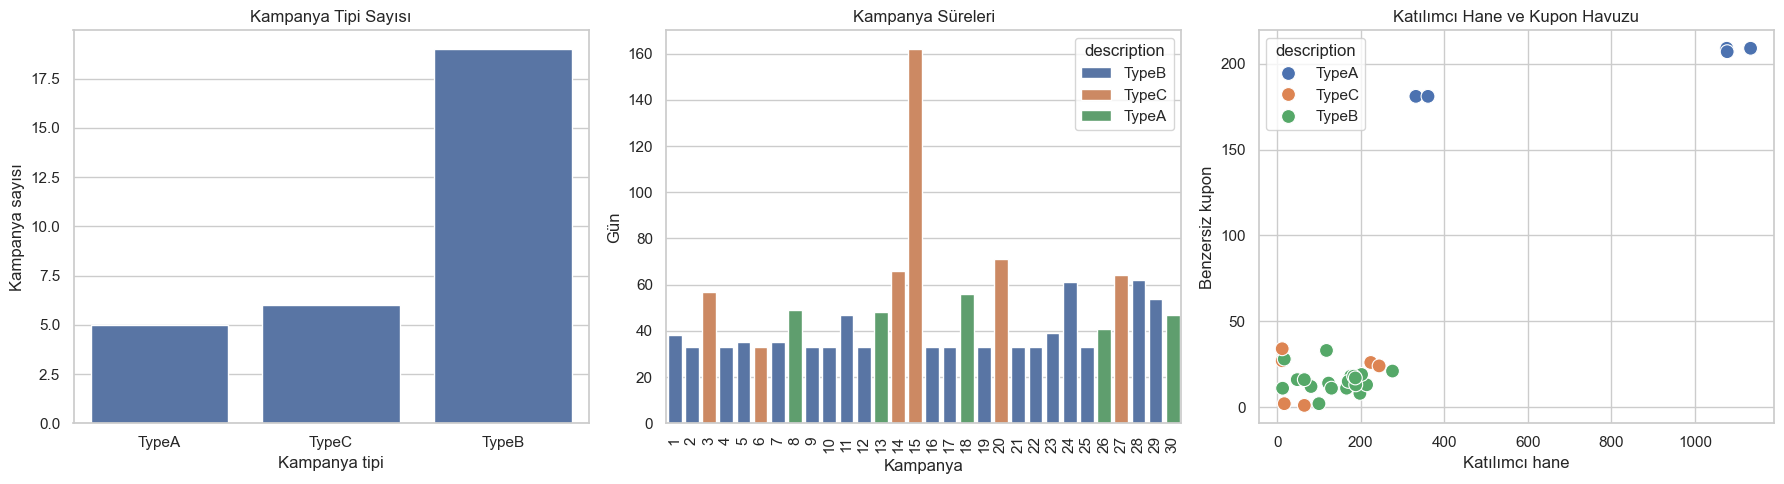

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=campaign_overview, x="description", ax=axes[0])
axes[0].set_title("Kampanya Tipi Sayısı")
axes[0].set_xlabel("Kampanya tipi")
axes[0].set_ylabel("Kampanya sayısı")

sns.barplot(
    data=campaign_overview.sort_values("duration_days", ascending=False),
    x="campaign", y="duration_days", hue="description", ax=axes[1]
)
axes[1].set_title("Kampanya Süreleri")
axes[1].tick_params(axis="x", rotation=90)
axes[1].set_xlabel("Kampanya")
axes[1].set_ylabel("Gün")

sns.scatterplot(
    data=campaign_overview,
    x="participant_households", y="distinct_coupon_upc",
    hue="description", s=100, ax=axes[2]
)
axes[2].set_title("Katılımcı Hane ve Kupon Havuzu")
axes[2].set_xlabel("Katılımcı hane")
axes[2].set_ylabel("Benzersiz kupon")

plt.tight_layout()
plt.show()


### Kampanya yapısına ilişkin bulgular

Veri setinde **5 Type A, 19 Type B ve 6 Type C** kampanya bulunmaktadır. Kampanya
tasarımları yalnızca kupon dağıtım kuralıyla değil, erişim ve süre bakımından da
belirgin biçimde ayrışmaktadır:

- Type A kampanyaların medyan katılımcı sayısı yaklaşık 1.076 hanedir ve erişimleri
  Type B/C kampanyalardan belirgin biçimde yüksektir.
- Type B kampanyaların medyan süresi 33 gündür; kampanyaların çoğu bu tiptedir.
- Type C kampanyaların medyan süresi 65 gündür; ancak katılımcı sayıları genellikle
  daha düşüktür.
- Campaign 15, 162 günlük süresiyle diğer kampanyalardan belirgin biçimde ayrılır.

Katılımcı sayısı ile kupon havuzu grafiği kampanya büyüklüğünü gösterir; ancak Type A
noktalarında `distinct_coupon_upc` değeri hane başına gönderilen kupon sayısı olarak
yorumlanmamalıdır. Her Type A hanesi bu havuzdan yalnızca 16 seçilmiş kupon almıştır.


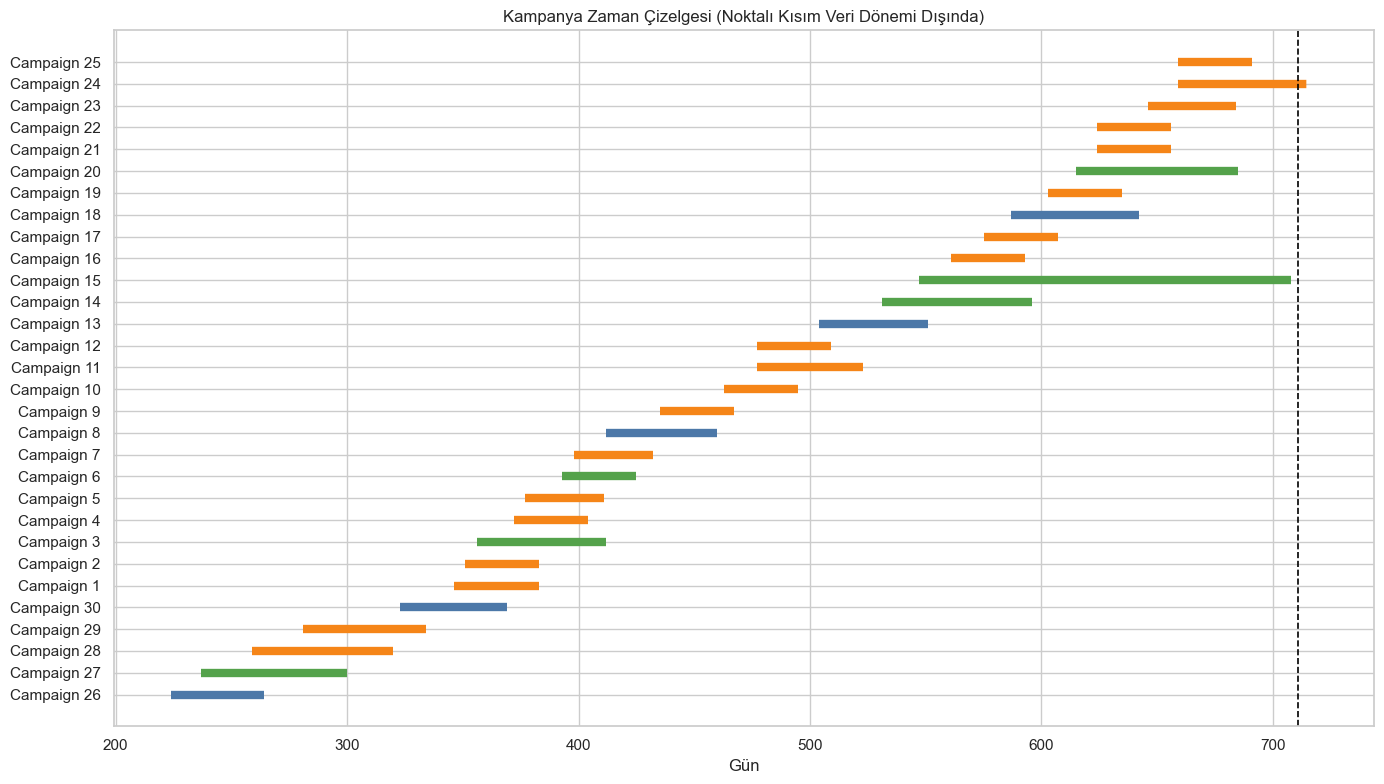

In [25]:
timeline = campaign_overview.sort_values(["start_day", "campaign"]).reset_index(drop=True)
palette = {"TypeA": "#4C78A8", "TypeB": "#F58518", "TypeC": "#54A24B"}

fig, ax = plt.subplots(figsize=(14, 8))
for y, row in timeline.iterrows():
    color = palette.get(row["description"], "gray")
    ax.hlines(y, row["start_day"], row["observed_end_day"], color=color, linewidth=6)
    if not row["complete_campaign_window"]:
        ax.hlines(
            y, row["observed_end_day"], row["end_day"],
            color=color, linewidth=6, linestyle=":"
        )

ax.axvline(transaction_end_day, color="black", linestyle="--", linewidth=1.2)
ax.set_yticks(range(len(timeline)))
ax.set_yticklabels([f"Campaign {c}" for c in timeline["campaign"]])
ax.set_xlabel("Gün")
ax.set_ylabel("")
ax.set_title("Kampanya Zaman Çizelgesi (Noktalı Kısım Veri Dönemi Dışında)")
plt.tight_layout()
plt.show()


### Tam gözlemlenmeyen kampanya

İşlem verisi 711. günde sona ererken Campaign 24, 719. güne kadar sürer. Bu nedenle
Campaign 24'ün son 8 günü gözlenmez. Kampanya, envanter ve zaman çizelgesinde
korunur; ancak tamamlanmış kampanyalarla yapılan kullanım oranı, kampanya tipi
performansı ve kampanya öncesi–dönemi karşılaştırmalarına dahil edilmez. Aksi halde
daha kısa gözlenen kullanım süresi Campaign 24'ün oranlarını yapay olarak düşük
gösterebilir.


## 4. Kupon kullanımlarının kampanya penceresiyle doğrulanması

User Guide'a göre kuponlar yalnızca `campaign_desc` tablosundaki başlangıç ve bitiş
günleri arasında geçerlidir. Bu nedenle her kullanım kaydı için iki iş kuralı
doğrulanır:

1. Kullanım günü kampanya tarih aralığında mı?
2. Kuponu kullanan hane `campaign_table` içinde ilgili kampanyayı almış mı?

İkinci kontrol kuponun haneye özel gönderim listesini doğrulamaz. Özellikle Type A'da
hangi 16 kuponun gönderildiği bilinmediğinden yalnızca hanenin kampanya katılımcısı
olduğu doğrulanabilir.


In [26]:
redemption_check = (
    coupon_redempt
    .merge(
        campaign_desc[["campaign", "description", "start_day", "end_day"]],
        on="campaign",
        how="left",
        validate="many_to_one",
    )
)

redemption_check["within_campaign_window"] = redemption_check["day"].between(
    redemption_check["start_day"],
    redemption_check["end_day"],
    inclusive="both",
)

campaign_household_pairs = pd.MultiIndex.from_frame(
    campaign_table[["household_key", "campaign"]].drop_duplicates()
)
redemption_pairs = pd.MultiIndex.from_frame(
    redemption_check[["household_key", "campaign"]]
)
redemption_check["household_received_campaign"] = redemption_pairs.isin(
    campaign_household_pairs
)

pd.DataFrame({
    "check": ["Kampanya tarihinde kullanım", "Haneye gönderilmiş kampanya"],
    "valid_count": [
        redemption_check["within_campaign_window"].sum(),
        redemption_check["household_received_campaign"].sum(),
    ],
    "invalid_count": [
        (~redemption_check["within_campaign_window"]).sum(),
        (~redemption_check["household_received_campaign"]).sum(),
    ],
})


,check,valid_count,invalid_count
0,Kampanya tarihinde kullanım,2318,0
1,Haneye gönderilmiş kampanya,2318,0


### Kupon kullanım kayıtlarının geçerliliği

Toplam **2.318 kupon kullanım kaydının tamamı** ilgili kampanyanın başlangıç ve
bitiş günleri arasındadır. Ayrıca kupon kullanan hanelerin tamamı ilgili kampanyayı
`campaign_table` kayıtlarına göre almıştır. Tarih dışı veya kampanya ataması olmayan
bir kullanım kaydı bulunmamaktadır.

Bu sonuç, `coupon_redempt` tablosunun kampanya ve hane ilişkileri bakımından tutarlı
olduğunu gösterir. Bununla birlikte Type A için kullanılan kuponun haneye gönderilen
16 kupondan biri olduğu veri tabanından bağımsız olarak yeniden doğrulanamaz.


## 5. Kampanya bazında kupon kullanımı

Bu bölüm iki farklı performans göstergesini ayırır:

1. **Kupon kullanan hane oranı:** En az bir kupon kullanan hane sayısının kampanyayı
   alan hane sayısına oranıdır. Paydası bütün kampanya tiplerinde bilindiği için
   Type A/B/C için hesaplanabilir.
2. **Benzersiz kupon kullanım oranı:** Kullanılan benzersiz hane–kampanya–kupon
   fırsatlarının toplam kupon fırsatlarına oranıdır. Type A'da haneye gönderilen 16
   kupon bilinmediği için yalnızca Type B/C için hesaplanabilir.

Aynı kupon birden fazla üründe geçerli olabildiğinden kullanım paydasında
`coupon-product` satır sayısı değil, **benzersiz `coupon_upc` sayısı** kullanılır.

Type B ve Type C kampanyaları için:

$$
\text{Kupon kullanım oranı}
=
\frac{
N_{\text{benzersiz hane–kampanya–kupon kullanımı}}
}{
N_{\text{katılımcı hane}}
\times
N_{\text{kampanyadaki benzersiz kupon}}
}
$$

Burada pay, benzersiz `(household_key, campaign, coupon_upc)` kullanımlarını;
payda ise kampanyaya katılan hane sayısı ile kampanyadaki benzersiz kupon
sayısının çarpımını gösterir.


In [27]:
unique_redemptions = coupon_redempt.drop_duplicates(
    ["household_key", "campaign", "coupon_upc"]
)

redemption_summary = (
    unique_redemptions.groupby("campaign")
    .agg(
        unique_redemption_events=("coupon_upc", "size"),
        redeeming_households=("household_key", "nunique"),
        distinct_redeemed_coupons=("coupon_upc", "nunique"),
    )
    .reset_index()
)

campaign_performance = campaign_overview.merge(
    redemption_summary,
    on="campaign",
    how="left",
    validate="one_to_one",
)

redemption_cols = [
    "unique_redemption_events",
    "redeeming_households",
    "distinct_redeemed_coupons",
]

campaign_performance[redemption_cols] = (
    campaign_performance[redemption_cols].fillna(0)
)

campaign_performance["redeeming_household_rate"] = (
    campaign_performance["redeeming_households"]
    / campaign_performance["participant_households"]
)

valid_denominator = (
    campaign_performance["description"].isin(["TypeB", "TypeC"])
    & campaign_performance["complete_campaign_window"]
)

campaign_performance["coupon_redemption_rate"] = np.nan

campaign_performance.loc[valid_denominator, "coupon_redemption_rate"] = (
    campaign_performance.loc[valid_denominator, "unique_redemption_events"]
    / (
        campaign_performance.loc[valid_denominator, "participant_households"]
        * campaign_performance.loc[valid_denominator, "distinct_coupon_upc"]
    )
)

campaign_performance.sort_values(
    "redeeming_household_rate",
    ascending=False,
)

,description,campaign,start_day,end_day,duration_days,observed_end_day,observed_duration_days,complete_campaign_window,participant_households,distinct_coupon_upc,eligible_products,coupon_product_links,unique_redemption_events,redeeming_households,distinct_redeemed_coupons,redeeming_household_rate,coupon_redemption_rate
22,TypeA,18,587,642,56,642,56,True,1133,209,35513,37480,646,214,121,0.189,NaN
17,TypeA,13,504,551,48,551,48,True,1077,207,35616,38075,620,196,129,0.182,NaN
7,TypeC,3,356,412,57,412,57,True,12,34,506,740,2,2,2,0.167,0.005
12,TypeA,8,412,460,49,460,49,True,1076,209,17178,18598,368,158,105,0.147,NaN
28,TypeB,25,659,691,33,691,33,True,187,17,826,826,59,24,15,0.128,0.019
27,TypeB,23,646,684,39,684,39,True,183,18,767,767,59,23,16,0.126,0.018
19,TypeC,15,547,708,162,708,162,True,17,2,55,55,2,2,2,0.118,0.059
23,TypeB,19,603,635,33,635,33,True,130,11,375,375,27,15,9,0.115,0.019
13,TypeB,9,435,467,33,467,33,True,176,18,825,825,43,20,14,0.114,0.014
3,TypeB,29,281,334,54,334,54,True,118,33,689,689,23,13,17,0.110,0.006


In [28]:
complete_campaign_performance = campaign_performance.loc[
    campaign_performance["complete_campaign_window"]
].copy()

type_performance = (
    complete_campaign_performance.groupby("description")
    .agg(
        campaign_count=("campaign", "nunique"),
        median_duration_days=("duration_days", "median"),
        total_campaign_assignments=("participant_households", "sum"),
        median_participant_households=("participant_households", "median"),
        total_unique_redemption_events=("unique_redemption_events", "sum"),
        median_redeeming_household_rate=(
            "redeeming_household_rate",
            "median",
        ),
    )
    .reset_index()
)

type_performance

,description,campaign_count,median_duration_days,total_campaign_assignments,median_participant_households,total_unique_redemption_events,median_redeeming_household_rate
0,TypeA,5,48.000,3979,"1,076.000",1771,0.147
1,TypeB,18,33.000,2555,168.000,434,0.075
2,TypeC,6,65.000,574,41.000,73,0.083


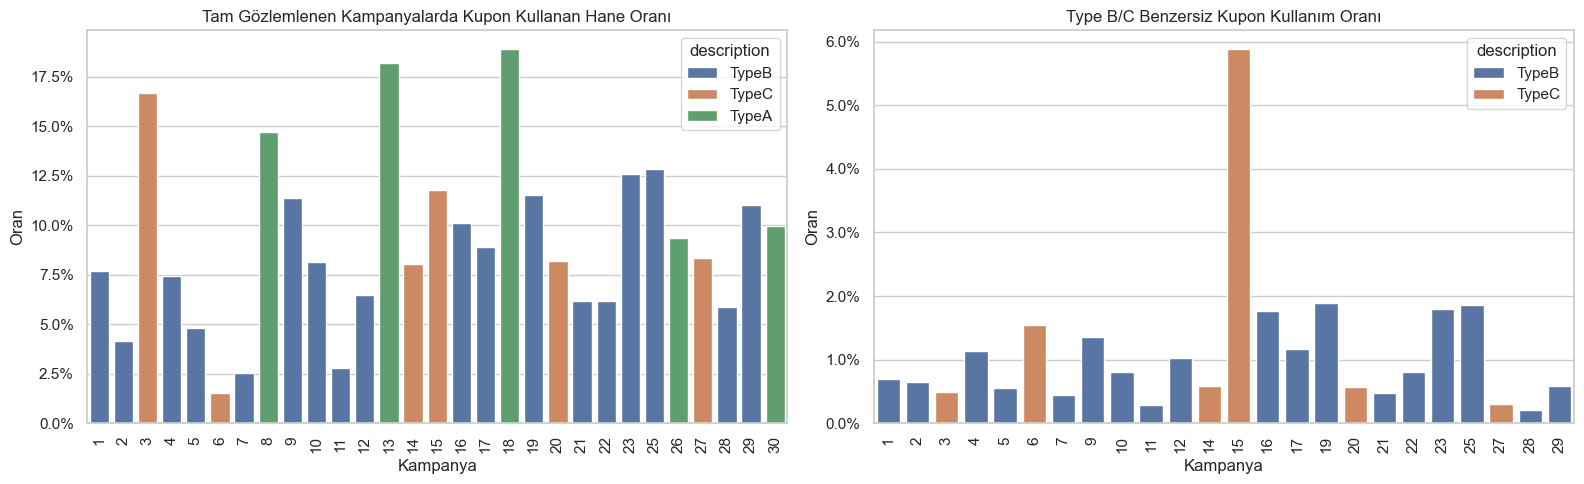

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_perf = complete_campaign_performance.sort_values(
    "redeeming_household_rate", ascending=False
)
sns.barplot(
    data=plot_perf,
    x="campaign", y="redeeming_household_rate",
    hue="description", ax=axes[0]
)
axes[0].set_title("Tam Gözlemlenen Kampanyalarda Kupon Kullanan Hane Oranı")
axes[0].tick_params(axis="x", rotation=90)
axes[0].set_xlabel("Kampanya")
axes[0].set_ylabel("Oran")
axes[0].yaxis.set_major_formatter(PercentFormatter(1.0))

valid_rate = campaign_performance.dropna(subset=["coupon_redemption_rate"])
sns.barplot(
    data=valid_rate.sort_values("coupon_redemption_rate", ascending=False),
    x="campaign", y="coupon_redemption_rate",
    hue="description", ax=axes[1]
)
axes[1].set_title("Type B/C Benzersiz Kupon Kullanım Oranı")
axes[1].tick_params(axis="x", rotation=90)
axes[1].set_xlabel("Kampanya")
axes[1].set_ylabel("Oran")
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))

plt.tight_layout()
plt.show()


### Kupon kullanımına ilişkin bulgular

Tam gözlemlenen kampanyalarda kupon kullanan hane oranı kampanyalar arasında
belirgin biçimde değişmektedir. En yüksek oranlar Campaign 18 Type A'da %18,9
ve Campaign 13 Type A'da %18,2 olarak gözlenmiştir.

Campaign 3 Type C'de kupon kullanan hane oranı %16,7 görünmektedir. Ancak bu
kampanya yalnızca 12 haneyi kapsadığı için oran az sayıdaki gözleme dayanmaktadır.
Bu nedenle Campaign 3 sonucu, daha fazla haneye ulaşan kampanyalarla doğrudan
karşılaştırılmamalıdır.

Kampanya tipi düzeyinde Type A kampanyalarının medyan kupon kullanan hane oranı
Type B ve Type C kampanyalarından daha yüksektir. Bununla birlikte Type A
kampanyalarında hanelere geçmiş satın alma davranışlarına göre seçilen 16 kupon
gönderilmektedir. Type B ve Type C'de ise kampanyaya katılan tüm haneler ilgili
kampanyadaki bütün kuponları almaktadır. Bu nedenle kampanya tipleri arasındaki
fark yalnızca kampanya tipinin başarısı veya etkisi olarak yorumlanamaz.

Type B ve Type C kampanyalarında benzersiz kupon kullanım oranları genel olarak
düşüktür. Campaign 15 Type C'de oran yaklaşık %5,9 ile görece yüksek görünmektedir.
Ancak bu sonuç yalnızca 17 katılımcı hane, iki kupon ve iki benzersiz
hane–kampanya–kupon kullanımına dayanmaktadır. Küçük paydalar oranları kolayca
yükseltebildiği için kullanım oranları katılımcı ve kullanım sayılarıyla birlikte
değerlendirilmelidir.

> Campaign 24'ün son sekiz günü işlem verisinde bulunmadığından kampanya performans
> grafiklerinden ve kampanya tipi özetinden çıkarılmıştır. Kampanya, veri envanteri
> tablosunda bilgi kaybını önlemek amacıyla korunmuştur.

## 6. Kampanya öncesi ve kampanya dönemi davranışı

Katılımcı hanelerin kampanya dönemindeki ortalama günlük müşteri harcaması,
kampanyadan hemen önceki eşit uzunluktaki dönemle karşılaştırılır. Örneğin 33 günlük
bir kampanya için kampanyadan önceki 33 gün referans dönemidir. Dönem uzunluklarının
eşit tutulması, farklı süreli kampanyaların daha karşılaştırılabilir olmasını sağlar.

Sepet sayısı ve aktif gün sayısı da hane düzeyindeki karşılaştırma tablosunda
üretilmektedir. Bununla birlikte bu notebooktaki kampanya düzeyi özet ve görseller,
ana parasal davranış göstergesi olan günlük müşteri harcamasına odaklanmaktadır.
Hiç alışveriş yapmayan katılımcılar sıfır değerle korunur; böylece analiz yalnızca
aktif müşterilerle sınırlandırılmaz.

### Parasal metriğin tanımı

Müşteri davranışı ölçüldüğü için `sales_value` yerine ilk üç notebook'la aynı tanım olan
`customer_paid_value = sales_value + coupon_disc` kullanılır. Böylece perakendecinin
elde ettiği gelir ile müşterinin ödediği tahmini tutar birbirine karıştırılmaz.

### Bu karşılaştırma neyi ölçmez?

Analiz, katılımcı hanenin dönemdeki **bütün alışverişlerini** toplar; yalnızca kuponun
geçerli olduğu ürünlerin satışını ölçmez. Ayrıca kontrol grubu yoktur, kampanyalar
birbiriyle çakışabilir ve katılımcılar geçmiş davranışlarına göre seçilmiş olabilir.

> Bu nedenle sonuçlar “kampanya döneminde gözlenen değişim” olarak ifade edilir;
> “kampanya harcamayı artırdı/azalttı” biçiminde nedensel yorum yapılmaz.


In [30]:
def period_household_metrics(transactions, households, start_day, end_day):
    period = transactions.loc[
        transactions["household_key"].isin(households)
        & transactions["day"].between(start_day, end_day, inclusive="both")
    ]

    return (
        period.groupby("household_key")
        .agg(
            customer_spend=("customer_paid_value", "sum"),
            baskets=("basket_id", "nunique"),
            active_days=("day", "nunique"),
        )
    )


campaign_change_records = []

complete_campaigns = campaign_overview.loc[
    campaign_overview["complete_campaign_window"]
]

for row in complete_campaigns.itertuples(index=False):
    households = campaign_table.loc[
        campaign_table["campaign"].eq(row.campaign), "household_key"
    ].unique()

    duration = int(row.end_day - row.start_day + 1)
    pre_start = int(row.start_day - duration)
    pre_end = int(row.start_day - 1)

    pre = period_household_metrics(
        transaction_data, households, pre_start, pre_end
    ).add_prefix("pre_")
    during = period_household_metrics(
        transaction_data, households, int(row.start_day), int(row.end_day)
    ).add_prefix("during_")

    household_index = pd.Index(households, name="household_key")
    comparison = (
        pd.DataFrame(index=household_index)
        .join(pre, how="left")
        .join(during, how="left")
        .fillna(0)
        .reset_index()
    )

    pre_days = max(pre_end - pre_start + 1, 1)
    during_days = duration
    comparison["pre_spend_per_day"] = (
        comparison["pre_customer_spend"] / pre_days
    )
    comparison["during_spend_per_day"] = (
        comparison["during_customer_spend"] / during_days
    )
    comparison["spend_per_day_change"] = (
        comparison["during_spend_per_day"]
        - comparison["pre_spend_per_day"]
    )
    comparison["campaign"] = row.campaign
    comparison["description"] = row.description
    comparison["complete_pre_window"] = pre_start >= transaction_start_day

    campaign_change_records.append(comparison)

campaign_household_change = pd.concat(campaign_change_records, ignore_index=True)
campaign_household_change.head()


,household_key,pre_customer_spend,pre_baskets,pre_active_days,during_customer_spend,during_baskets,during_active_days,pre_spend_per_day,during_spend_per_day,spend_per_day_change,campaign,description,complete_pre_window
0,17,284.380,9.000,6.000,433.820,13.000,10.000,6.936,10.581,3.645,26,TypeA,True
1,27,5.490,1.000,1.000,189.520,8.000,8.000,0.134,4.622,4.489,26,TypeA,True
2,212,143.970,9.000,8.000,106.530,4.000,4.000,3.511,2.598,-0.913,26,TypeA,True
3,208,157.350,6.000,6.000,159.430,5.000,5.000,3.838,3.889,0.051,26,TypeA,True
4,192,213.230,5.000,5.000,208.540,5.000,5.000,5.201,5.086,-0.114,26,TypeA,True


In [31]:
campaign_change_summary = (
    campaign_household_change.groupby(["campaign", "description"])
    .agg(
        participant_households=("household_key", "nunique"),
        mean_pre_spend_per_day=("pre_spend_per_day", "mean"),
        mean_during_spend_per_day=("during_spend_per_day", "mean"),
        median_spend_per_day_change=("spend_per_day_change", "median"),
        share_with_spend_increase=("spend_per_day_change", lambda s: s.gt(0).mean()),
    )
    .reset_index()
)

campaign_change_summary


,campaign,description,participant_households,mean_pre_spend_per_day,mean_during_spend_per_day,median_spend_per_day_change,share_with_spend_increase
0,1,TypeB,13,6.452,7.515,0.315,0.538
1,2,TypeB,48,7.230,7.232,0.107,0.521
2,3,TypeC,12,12.713,12.421,-1.334,0.417
3,4,TypeB,81,9.428,9.857,-0.065,0.494
4,5,TypeB,166,12.151,12.309,0.205,0.512
5,6,TypeC,65,14.676,14.612,0.121,0.508
6,7,TypeB,198,10.339,10.601,0.098,0.515
7,8,TypeA,1076,8.055,7.965,0.000,0.494
8,9,TypeB,176,9.077,8.154,-0.927,0.415
9,10,TypeB,123,11.608,10.872,-0.899,0.423


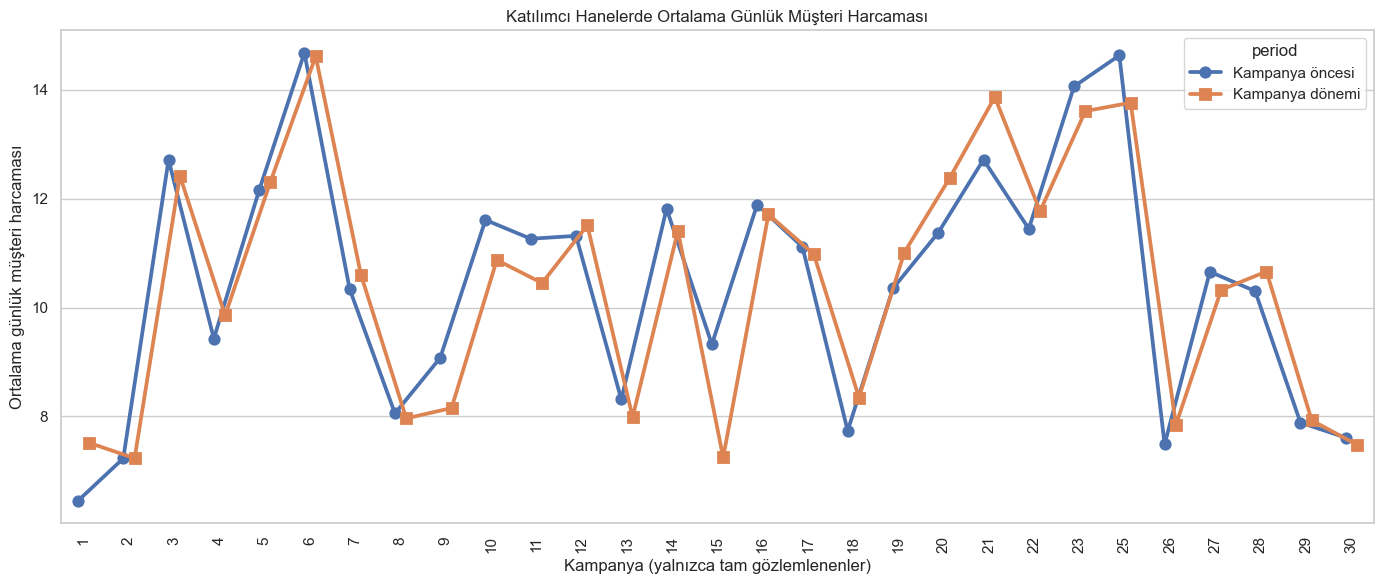

In [32]:
change_long = campaign_change_summary.melt(
    id_vars=["campaign", "description"],
    value_vars=["mean_pre_spend_per_day", "mean_during_spend_per_day"],
    var_name="period", value_name="mean_spend_per_day",
)
change_long["period"] = change_long["period"].map({
    "mean_pre_spend_per_day": "Kampanya öncesi",
    "mean_during_spend_per_day": "Kampanya dönemi",
})

plt.figure(figsize=(14, 6))
sns.pointplot(
    data=change_long, x="campaign", y="mean_spend_per_day",
    hue="period", dodge=0.25, markers=["o", "s"]
)
plt.title("Katılımcı Hanelerde Ortalama Günlük Müşteri Harcaması")
plt.xlabel("Kampanya (yalnızca tam gözlemlenenler)")
plt.ylabel("Ortalama günlük müşteri harcaması")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


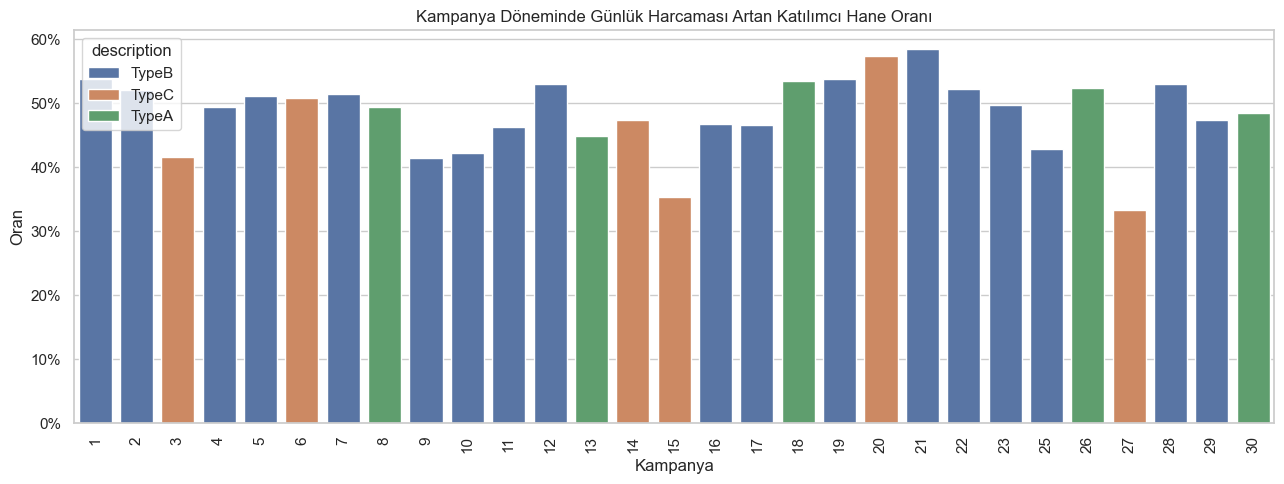

In [33]:
plt.figure(figsize=(13, 5))
sns.barplot(
    data=campaign_change_summary.sort_values("share_with_spend_increase", ascending=False),
    x="campaign", y="share_with_spend_increase", hue="description"
)
plt.title("Kampanya Döneminde Günlük Harcaması Artan Katılımcı Hane Oranı")
plt.xlabel("Kampanya")
plt.ylabel("Oran")
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


### Kampanya dönemindeki harcama değişimine ilişkin bulgular

Ortalama günlük müşteri harcaması, medyan hane değişimi ve harcaması artan hane
oranı birlikte değerlendirildiğinde Campaign 21, Campaign 20 ve Campaign 18'de
tutarlı bir pozitif örüntü görülmektedir:

- **Campaign 21:** Ortalama günlük müşteri harcaması 12,72'den 13,86'ya yükselmiştir.
  Medyan hane değişimi +1,00'dır ve katılımcı hanelerin %58,5'inde günlük harcama
  artmıştır.
- **Campaign 20:** Ortalama günlük müşteri harcaması 11,37'den 12,37'ye yükselmiştir.
  Medyan değişim +0,52'dir ve hanelerin %57,4'ünde artış gözlenmiştir.
- **Campaign 18:** Ortalama günlük müşteri harcaması 7,74'ten 8,35'e yükselmiştir.
  Medyan değişim +0,21'dir ve hanelerin %53,5'inde artış görülmüştür.

Negatif yöndeki en belirgin örüntülerden biri Campaign 15'te görülmektedir.
Ortalama günlük müşteri harcaması 9,32'den 7,25'e gerilemiş, medyan hane değişimi
-1,20 olmuş ve hanelerin yalnızca %35,3'ünde artış gözlenmiştir. Campaign 9,
Campaign 10 ve Campaign 25'te de ortalama ve medyan değişimler birlikte negatif
yöndedir.

Campaign 27'de harcaması artan hane oranı %33,3 ile en düşük seviyededir. Ancak
kampanya yalnızca 12 haneyi kapsadığı için bu oran yüksek örneklem belirsizliği
taşımaktadır.

Bu sonuçlar kampanya dönemindeki davranış değişimini tanımlamaktadır. Kontrol grubu
bulunmadığından, gözlenen artış veya azalışların kampanyalardan kaynaklandığı
sonucuna varılamaz.

### Kampanya öncesi–dönemi karşılaştırmasını okuma

İlk grafik, her kampanya için katılımcı hanelerin ortalama günlük müşteri harcamasını
önceki eşit uzunluktaki dönemle karşılaştırır. İki nokta arasındaki farkın büyük olması
ortalama davranışta değişim olduğunu gösterir; ancak ortalama az sayıdaki yüksek
harcamalı haneden etkilenebilir.

İkinci grafik bu nedenle tamamlayıcıdır: günlük harcaması artan katılımcı hanelerin
oranını gösterir. Yaklaşık %50'lik bir değer artış ve azalış yaşayan hanelerin dengeli
olduğunu; %50'nin üzerindeki değer ise artış yaşayan hanelerin çoğunlukta olduğunu
gösterir. `median_spend_per_day_change` metriği de tipik hanedeki değişimin yönünü
kontrol etmek için kullanılır.

Sonuçlar yorumlanırken üç koşul birlikte değerlendirilmelidir:

1. Ortalama günlük harcama hangi yönde değişmiş?
2. Medyan hane değişimi aynı yönü gösteriyor mu?
3. Harcaması artan hanelerin payı %50'nin üzerinde mi?

Bu üç göstergenin aynı yönde olması daha tutarlı bir tanımlayıcı örüntü sağlar; yine
de kontrol grubu olmadığı için kampanya etkisini kanıtlamaz.


## 7. Hane düzeyinde kampanya özelliklerinin önizlemesi

Kampanya tabloları kampanya–hane ve kupon kullanım satırları içerirken modelin analiz
birimi hanedir. Bu bölüm ilişkisel kayıtların `household_key` düzeyinde nasıl
özetlenebileceğini gösteren bir önizlemedir.

Üretilen özelliklerin anlamı:

- `total_campaigns_received`: Hanenin aldığı benzersiz toplam kampanya sayısı.
- `received_TypeA/B/C`: Hanenin aldığı kampanyaların tip bazındaki sayıları.
- `coupon_redemption_events`: Gözlenen toplam kupon kullanım kaydı.
- `unique_coupons_redeemed`: Hanenin kullandığı benzersiz kupon sayısı.
- `campaigns_with_redemption`: En az bir kupon kullanılan kampanya sayısı.
- `has_redeemed_coupon`: Hanenin herhangi bir kupon kullanıp kullanmadığı.
- `days_since_last_redemption`: Veri sonu ile son kupon kullanımı arasındaki gün sayısı.

> Bu tablo nihai feature engineering çıktısı değildir. Bütün veri dönemini kullandığı
> için doğrudan modele verilirse geleceğe ait bilgi içerebilir. Nihai özellikler yalnızca
> gözlem penceresinin sonuna kadar gerçekleşen kampanya ve kullanımlardan yeniden
> üretilmelidir.


In [34]:
campaign_received_features = (
    campaign_table.pivot_table(
        index="household_key",
        columns="description",
        values="campaign",
        aggfunc="nunique",
        fill_value=0,
    )
    .add_prefix("received_")
    .reset_index()
)

household_campaign_features = (
    campaign_table.groupby("household_key")
    .agg(total_campaigns_received=("campaign", "nunique"))
    .reset_index()
    .merge(campaign_received_features, on="household_key", how="left", validate="one_to_one")
)

household_redemption_features = (
    coupon_redempt.groupby("household_key")
    .agg(
        coupon_redemption_events=("coupon_upc", "size"),
        unique_coupons_redeemed=("coupon_upc", "nunique"),
        campaigns_with_redemption=("campaign", "nunique"),
        last_redemption_day=("day", "max"),
    )
    .reset_index()
)

household_campaign_features = household_campaign_features.merge(
    household_redemption_features,
    on="household_key",
    how="left",
    validate="one_to_one",
)

count_feature_cols = [
    "coupon_redemption_events",
    "unique_coupons_redeemed",
    "campaigns_with_redemption",
]
household_campaign_features[count_feature_cols] = (
    household_campaign_features[count_feature_cols].fillna(0).astype(int)
)
household_campaign_features["has_redeemed_coupon"] = (
    household_campaign_features["coupon_redemption_events"].gt(0).astype(int)
)
household_campaign_features["days_since_last_redemption"] = (
    transaction_end_day - household_campaign_features["last_redemption_day"]
)

household_campaign_features.to_parquet(
    INTERIM_PATH / "household_campaign_features_preview.parquet",
    index=False,
)

assert household_campaign_features["household_key"].is_unique
print("Önizleme tablo boyutu:", household_campaign_features.shape)
print("Kupon kullanan hane:", household_campaign_features["has_redeemed_coupon"].sum())

household_campaign_features.head()


Önizleme tablo boyutu: (1584, 11)
Kupon kullanan hane: 434


,household_key,total_campaigns_received,received_TypeA,received_TypeB,received_TypeC,coupon_redemption_events,unique_coupons_redeemed,campaigns_with_redemption,last_redemption_day,has_redeemed_coupon,days_since_last_redemption
0,1,8,3,4,1,5,5,2,597.000,1,114.000
1,2,1,1,0,0,0,0,0,NaN,0,NaN
2,3,3,2,0,1,0,0,0,NaN,0,NaN
3,4,1,1,0,0,0,0,0,NaN,0,NaN
4,6,4,3,1,0,0,0,0,NaN,0,NaN


### Özellik tablosunun kapsamı

Önizleme tablosu yalnızca en az bir kampanya alan **1.584 haneyi** içerir. Kupon
kullanmayan hanelerde kullanım sayıları sıfırdır; `last_redemption_day` ve
`days_since_last_redemption` ise bilinçli olarak `NaN` bırakılır. “Hiç kullanmadı”
durumunu sıfır gün önce kullanım gibi göstermek yanlış olacağı için zaman uzaklığına
yapay bir değer atanmaz.

Nihai model tablosu kurulurken bu önizleme bütün 2.500 hanelik ana evrene `left join`
ile bağlanmalıdır. Kampanya almayan hanelerde kampanya ve kullanım sayıları sıfır, son
kullanım tarihi ise eksik kalmalıdır. Böylece kampanya almama ile kampanya alıp kupon
kullanmama durumları birbirine karıştırılmaz.


## 8. Sonuç ve modellemeye aktarılacak kararlar

### Bir bakışta temel sonuç

Kampanya ve kupon tabloları teknik olarak tutarlıdır; ancak kampanya tipleri aynı
kupon dağıtım mekanizmasına sahip değildir. Type A'da haneye gönderilen 16 kupon
bilinmediği için gerçek kupon fırsatı paydası kurulamaz. Bu nedenle bütün kampanya
tiplerine tek bir kupon kullanım oranı uygulamak doğru değildir.

### Veri bütünlüğü

- Veri setinde 30 kampanya, kampanya alan 1.584 benzersiz hane, 1.135 benzersiz
  kupon ve 2.318 kupon kullanım kaydı vardır.
- Kampanya açıklamalarında, anahtar ilişkilerinde veya tablo eşleşmelerinde
  tutarsızlık bulunmamıştır.
- 2.318 kullanımın tamamı ilgili kampanya tarihleri içindedir ve kullanım yapan
  hanelerin tamamı ilgili kampanyayı almıştır.
- Campaign 15, başlangıç ve bitiş günleri dahil 162 gün ile süre bakımından aykırıdır.
- Campaign 24'ün son 8 günü işlem verisi dışında kaldığı için envanterde korunmuş,
  fakat performans karşılaştırmalarından çıkarılmıştır.

### Kupon davranışı ve User Guide kararı

- Kupon kullanan hane oranı bütün kampanya tiplerinde hesaplanabilir.
- Type B/C için her katılımcının bütün kampanya kuponlarını aldığı bilindiğinden
  benzersiz kupon kullanım oranı hesaplanabilir.
- Type A'da kupon havuzu bilinmesine rağmen haneye gönderilen 16 kupon bilinmez. Bu
  nedenle `coupon_redemption_rate` bilinçli olarak `NaN` bırakılır.
- Yüksek oranlar küçük katılımcı veya kupon paydalarından kaynaklanabileceği için oranlar
  her zaman hane ve kullanım sayılarıyla birlikte raporlanmalıdır.


### Kampanya dönemindeki harcama örüntüsü

- Campaign 21, Campaign 20 ve Campaign 18'de ortalama günlük harcama, medyan
  hane değişimi ve harcaması artan hane oranı birlikte pozitif yöndedir.
- Campaign 15'te ortalama günlük harcama 9,32'den 7,25'e gerilemiş ve katılımcı
  hanelerin yalnızca %35,3'ünde artış gözlenmiştir.
- Küçük katılımcı sayısına sahip kampanyaların oranları daha yüksek belirsizlik
  taşıdığı için oranlar örneklem büyüklükleriyle birlikte değerlendirilmelidir.
- Kontrol grubu bulunmadığından bu bulgular kampanya etkisi değil, kampanya
  döneminde gözlenen tanımlayıcı değişimlerdir.
  
### Kampanya dönemi davranışı

Kampanya öncesi–dönemi karşılaştırmasında müşterinin ödediği tahmini tutar kullanılır.
Ortalama günlük harcama, medyan hane değişimi ve harcaması artan hane oranı birlikte
değerlendirilir. Bununla birlikte hesaplama katılımcıların bütün alışverişlerini içerir;
kontrol grubu ve çakışan kampanya kontrolü olmadığı için sonuçlar kampanya etkisi
olarak yorumlanmaz.

### Feature engineering'e aktarılabilecek özellikler

- Gözlem döneminde alınan toplam ve Type A/B/C kampanya sayıları
- Kampanya alıp almama göstergesi ve son kampanyadan beri geçen süre
- Toplam ve benzersiz kupon kullanım sayıları
- Kupon kullanılan kampanya sayısı ve kupon kullanma göstergesi
- Son kupon kullanımından beri geçen gün
- Kampanya başına ve aktif dönem başına kupon kullanım sıklığı
- Kampanya dönemindeki harcama/sepet değişimi

### Sınırlılıklar

- Type A için gerçek kupon fırsatı sayısı bilinmez.
- Kampanya alan haneler rastgele seçilmemiş olabilir.
- Kampanyalar zaman bakımından çakışabilir ve aynı hane birden fazla kampanya alabilir.
- `causal_data` kullanılmadığı için mağaza içi gösterim ve broşür etkisi kontrol edilmez.
- Kupon kullanmayanlarda son kullanım tarihi sıfır yapılmaz; `NaN` olarak korunur.
- Bütün özellikler nihai modelde gözlem penceresinin son gününe göre yeniden üretilmelidir.

Kaçınılması gereken ifade:

> “Type A kampanyaları satışları artırdığı için daha başarılıdır.”

Kullanılabilecek ifade:

> “Type A kampanyalarında en az bir kupon kullanan hane oranı daha yüksek görünmektedir;
> ancak kampanyalar kişiselleştirilmiş kupon seçimi, erişim ve hedef müşteri yapısı
> bakımından farklı olduğundan bu sonuç nedensel bir kampanya tipi etkisi değildir.”

**Sonraki adım:** Hedef ve gözlem penceresi kesinleştirildikten sonra işlem, ürün,
demografi ve kampanya özellikleri `household_key` düzeyinde birleştirilecektir.
